# Section 3 — Model Creation & Evaluation 
From our transform.ipynb notebook, we decided that we will compare our EDA-Informed features vs. PCA-Reduced features to see which would produce the best K value.

1. Load datasets
2. Use Elbow Method on both datasets
3. Use Silhouette Score Metric on both datasets
4. Select optimal K and winning feature dataset
5. Cluster Profiling
6. Saved Clustered Dataset

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, silhouette_samples
from sklearn.decomposition import PCA

In [19]:
# Style for visuals
PALETTE = sns.color_palette('husl', 15)
plt.style.use('dark_background')

## 1. Load Cleaned Data

We load two datasets saved from Notebook 2:
- **`cleaned_train.csv`** — the 15 eda-informed lyrical features (0–1 scale, no normalization needed) + `genre`
- **`cleaned_train_pca.csv`** — PCA-reduced version (7 or 8 components capturing ~84-88% variance) + `genre`

**Reminder:** \
`genre` is a reference label only — it will NOT be used as a clustering feature.


In [20]:
# Load both datasets
df_raw  = pd.read_csv('../data/cleaned_data/cleaned_train.csv')
df_pca  = pd.read_csv('../data/cleaned_data/cleaned_train_pca.csv')

print('Raw cleaned shape :', df_raw.shape)
print('PCA cleaned shape :', df_pca.shape)
print()
print('Raw columns:', df_raw.columns.tolist())
print('PCA columns:', df_pca.columns.tolist())

Raw cleaned shape : (28362, 16)
PCA cleaned shape : (28362, 8)

Raw columns: ['genre', 'dating', 'violence', 'world/life', 'night/time', 'shake the audience', 'family/gospel', 'romantic', 'communication', 'obscene', 'music', 'movement/places', 'light/visual perceptions', 'family/spiritual', 'sadness', 'feelings']
PCA columns: ['PC1', 'PC2', 'PC3', 'PC4', 'PC5', 'PC6', 'PC7', 'genre']


In [21]:
# Separate features from the genre feature
X_raw = df_raw.drop(columns=['genre']).values    # EDA-Informed (Raw)
X_pca = df_pca.drop(columns=['genre']).values    # PCA-Reduced

print(f'Shape (raw): {X_raw.shape}')
print(f'Shape (pca): {X_pca.shape}')

Shape (raw): (28362, 15)
Shape (pca): (28362, 7)


# 2. Elbow Method

Run the Elbow method on both EDA-informed(raw) features and PCA-reduced features

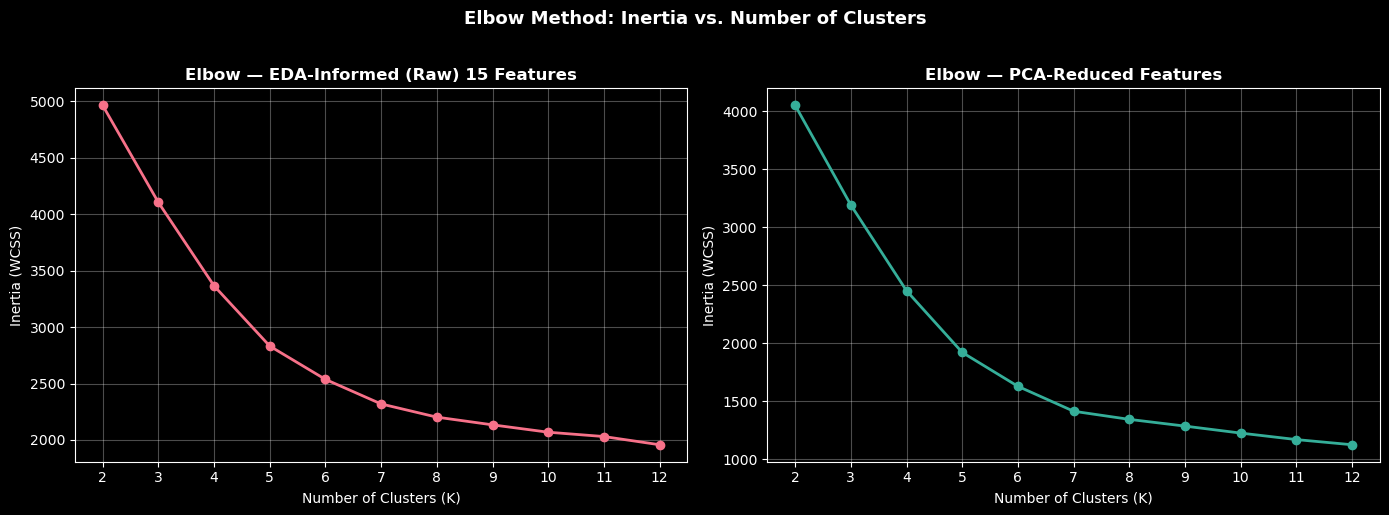

In [22]:
k_range = range(2, 13)  # test K from 2 to 12

def run_elbow(X, title, ax, color):
    '''Run KMeans for a range of K and plot inertia (WCSS) to find the elbow point.'''
    inertias = []
    for k in k_range:
        km = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=42) # create KMeans instance
        km.fit(X)   # fit model on train data
        inertias.append(km.inertia_)
    
    
    ax.plot(list(k_range), inertias, marker='o', color=color, linewidth=2)
    ax.set_title(title, fontsize=12, fontweight='bold', color='white')
    ax.set_xlabel('Number of Clusters (K)')
    ax.set_ylabel('Inertia (WCSS)')
    ax.set_xticks(list(k_range))
    ax.grid(alpha=0.3)
   
   
    return inertias

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Run elbow method on raw dataset (eda-informed features)
inertia_raw = run_elbow(X_raw, 'Elbow — EDA-Informed (Raw) 15 Features', axes[0], PALETTE[0])

# Run elbow method on PCA-reduced dataset
inertia_pca = run_elbow(X_pca, 'Elbow — PCA-Reduced Features', axes[1], PALETTE[7])

plt.suptitle('Elbow Method: Inertia vs. Number of Clusters', fontsize=13, 
             fontweight='bold', color='white', y=1.02)
plt.tight_layout()
plt.show()

Elbow Method uses WSS(Within-Cluster Sum of Squares) or inertia, is a metric to determine the optimal clusters (K) in our model. Optimal K is found at the elbow or where inertia stops dropping sharply (meaning adding more clusters stops helping much).

In our plots:
- EDA-Informed(Raw) flattens out around K=6 or K=7.
- PCA-Reduced has more defined elbow at K=7.

Both EDA-Informed(Raw) and PCA-Reduced features dropped steeply from K=2 to K=6 and after K=7, the inertia barely moves in smaller quantities.

## 3. Silhouette Score Analysis

In [23]:
def compute_silhouette(X, k_range, random_state=42):
    """Compute average silhouette score for each K."""
    scores = []
    for k in k_range:
        km = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=random_state)  # create KMeans instance
        labels = km.fit_predict(X)  # fit model on train data
        score = silhouette_score(X, labels) #compute silhouette score
        scores.append(score)
    return scores


# Call function to compute silhouette scores for both datasets
sil_raw = compute_silhouette(X_raw, k_range) # EDA-Informed (Raw) dataset
sil_pca = compute_silhouette(X_pca, k_range) # PCA-Reduced dataset

# Print table
print('\nSilhouette Scores by K:')
print(f'{"K":>3}  {"Raw":>8}  {"PCA":>8}')

for k, s1, s2 in zip(k_range, sil_raw, sil_pca):
    print(f'{k:>3}  {s1:>8.4f}  {s2:>8.4f}')


Silhouette Scores by K:
  K       Raw       PCA
  2    0.1844    0.2278
  3    0.2286    0.2827
  4    0.2752    0.3429
  5    0.3125    0.3908
  6    0.3316    0.4160
  7    0.3443    0.4338
  8    0.3493    0.3868
  9    0.2988    0.3486
 10    0.2538    0.2921
 11    0.2113    0.2588
 12    0.1738    0.2548


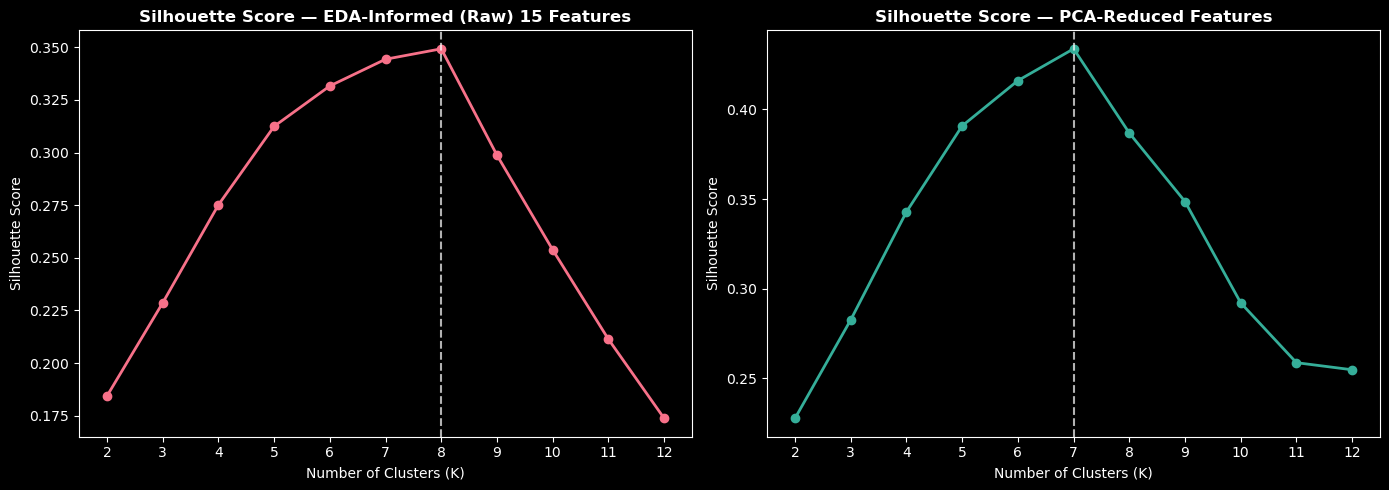

In [24]:
def plot_silhouette(ax, scores, title, color):
    '''Plot silhouette scores and mark best K.'''
    best_k = list(k_range)[np.argmax(scores)]
    ax.plot(list(k_range), scores, marker='o', color=color, linewidth=2)

    # Mark best K with dashed line
    ax.axvline(best_k, linestyle='--', color='white', alpha=0.7)

    ax.set_title(title, fontsize=12, fontweight='bold', color='white')
    ax.set_xlabel('Number of Clusters (K)')
    ax.set_ylabel('Silhouette Score')
    ax.set_xticks(list(k_range))


fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Call function to plot silhouette scores on both datasets
plot_silhouette(axes[0], sil_raw, 'Silhouette Score — EDA-Informed (Raw) 15 Features', PALETTE[0])
plot_silhouette(axes[1], sil_pca, 'Silhouette Score — PCA-Reduced Features', PALETTE[7])

plt.tight_layout()
plt.show()

Silhouette Score is a metric used to calculate the average distance between samples that belong/don'd belong to the same cluster where the most compact clusters = 1.

In our scores, we can see:
- PCA-reduced features silhouette scores consistently beats EDA-Informed features. It removed enough noise making the clusters tighter and separated better.
- PCA K=7 score= 0.4338 is the highest value in the table. Confirms the K-value we found in the Elbow Method.

# 4. Selecting Optimal K and Feature Set

Based on the Elbow Method and Silhouette Scores above, we now pick:
- Feature Set: PCA-Reduced dataset
- Optimal K: K = 7

In [25]:
# setting best K and dataset for final clustering
best_k = 7  # optimal K based on silhouette scores
X_best = X_pca # PCA-reduced dataset chosen 

In [26]:
# Create KMeans object with optimal number of clusters
kmeans = KMeans(n_clusters=7, init='k-means++', n_init=10, random_state=42)

# Fit KMeans using X_pca data
kmeans.fit(X_pca)

# Generate labels for the dataset
labels = kmeans.fit_predict(X_pca)
labels

array([5, 2, 1, ..., 4, 4, 4], shape=(28362,), dtype=int32)

In [27]:
# Output the centroids of your clusters
kmeans.cluster_centers_

array([[-1.11491478e-01,  3.06736651e-01, -8.87816489e-02,
        -4.34944851e-02,  6.11900370e-03,  6.64739013e-03,
        -1.55202868e-03],
       [ 9.53573696e-03, -2.56181964e-02,  7.04010833e-03,
         3.11792944e-01,  2.17890619e-01,  3.08165449e-02,
        -6.45628673e-02],
       [ 7.46488938e-02,  6.01857866e-03,  3.16428603e-01,
        -6.73257782e-02,  7.97078752e-03,  7.16455174e-03,
        -1.16097877e-02],
       [ 4.00994684e-02, -2.22314769e-02,  2.11692870e-02,
         1.71765361e-01, -1.30705451e-01,  9.51076217e-02,
         3.03174012e-01],
       [-3.03342945e-01, -2.36056927e-01, -5.79345414e-02,
        -7.29418706e-02,  1.08940217e-02,  4.73888644e-03,
         2.22085820e-04],
       [ 2.68474268e-01, -8.23456775e-02, -1.62678329e-01,
        -6.71272101e-02,  9.76764408e-03,  1.06111053e-03,
        -7.69521933e-03],
       [-9.27541336e-04, -1.73042215e-02,  4.08791581e-03,
         1.80433682e-01, -2.38757723e-01, -1.61449790e-01,
        -1.0677006

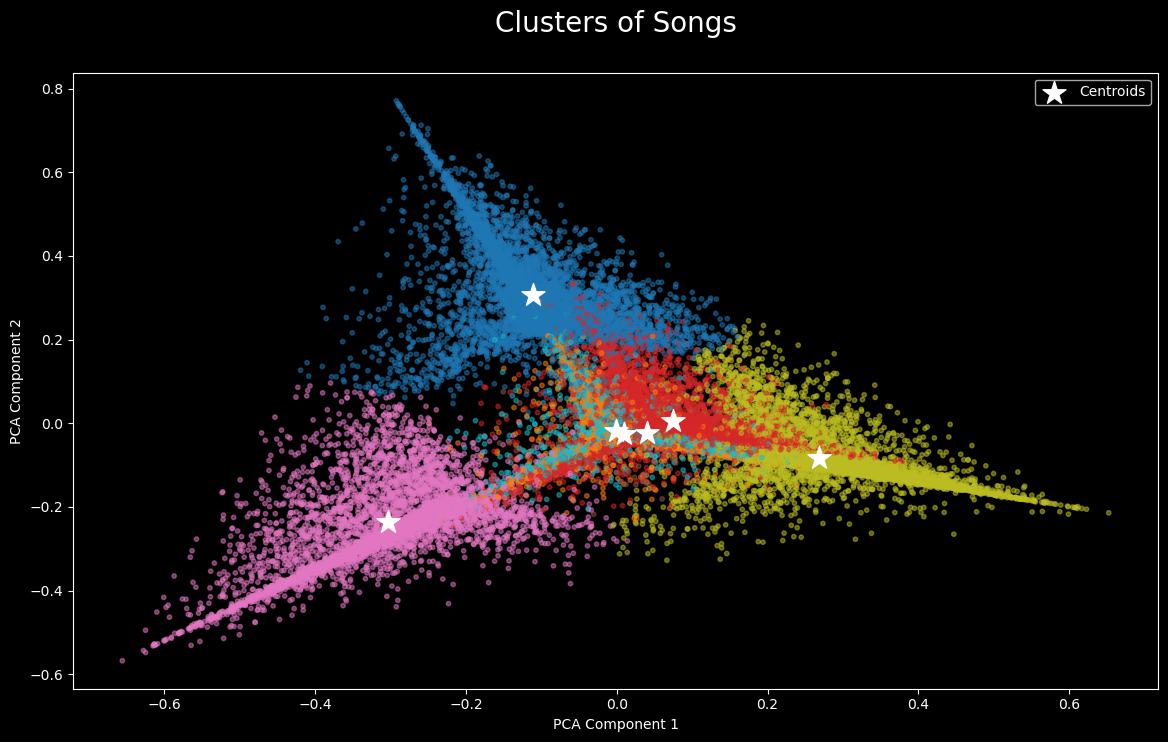

In [28]:
# View 2D clusters (using first 2 PCA components)
plt.figure(figsize=(14, 8))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=kmeans.labels_, s=10, cmap='tab10', alpha=0.5)
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], color='white', s=300, marker='*', label='Centroids')
plt.title('Clusters of Songs\n', fontsize=20)
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.legend()
plt.show()

In our plot above, each dot represents a song, positioned based on its two most important lyrical summary scores from PCA, with colors representing the 7 clusters KMeans assigned using all 7 PCA components. Dense centers are represented by a star.

Songs that share similar lyrical profiles end up close together, while the distinct arms extending outward represent clusters of songs with strong, unique lyrical identities that set them apart from the center.

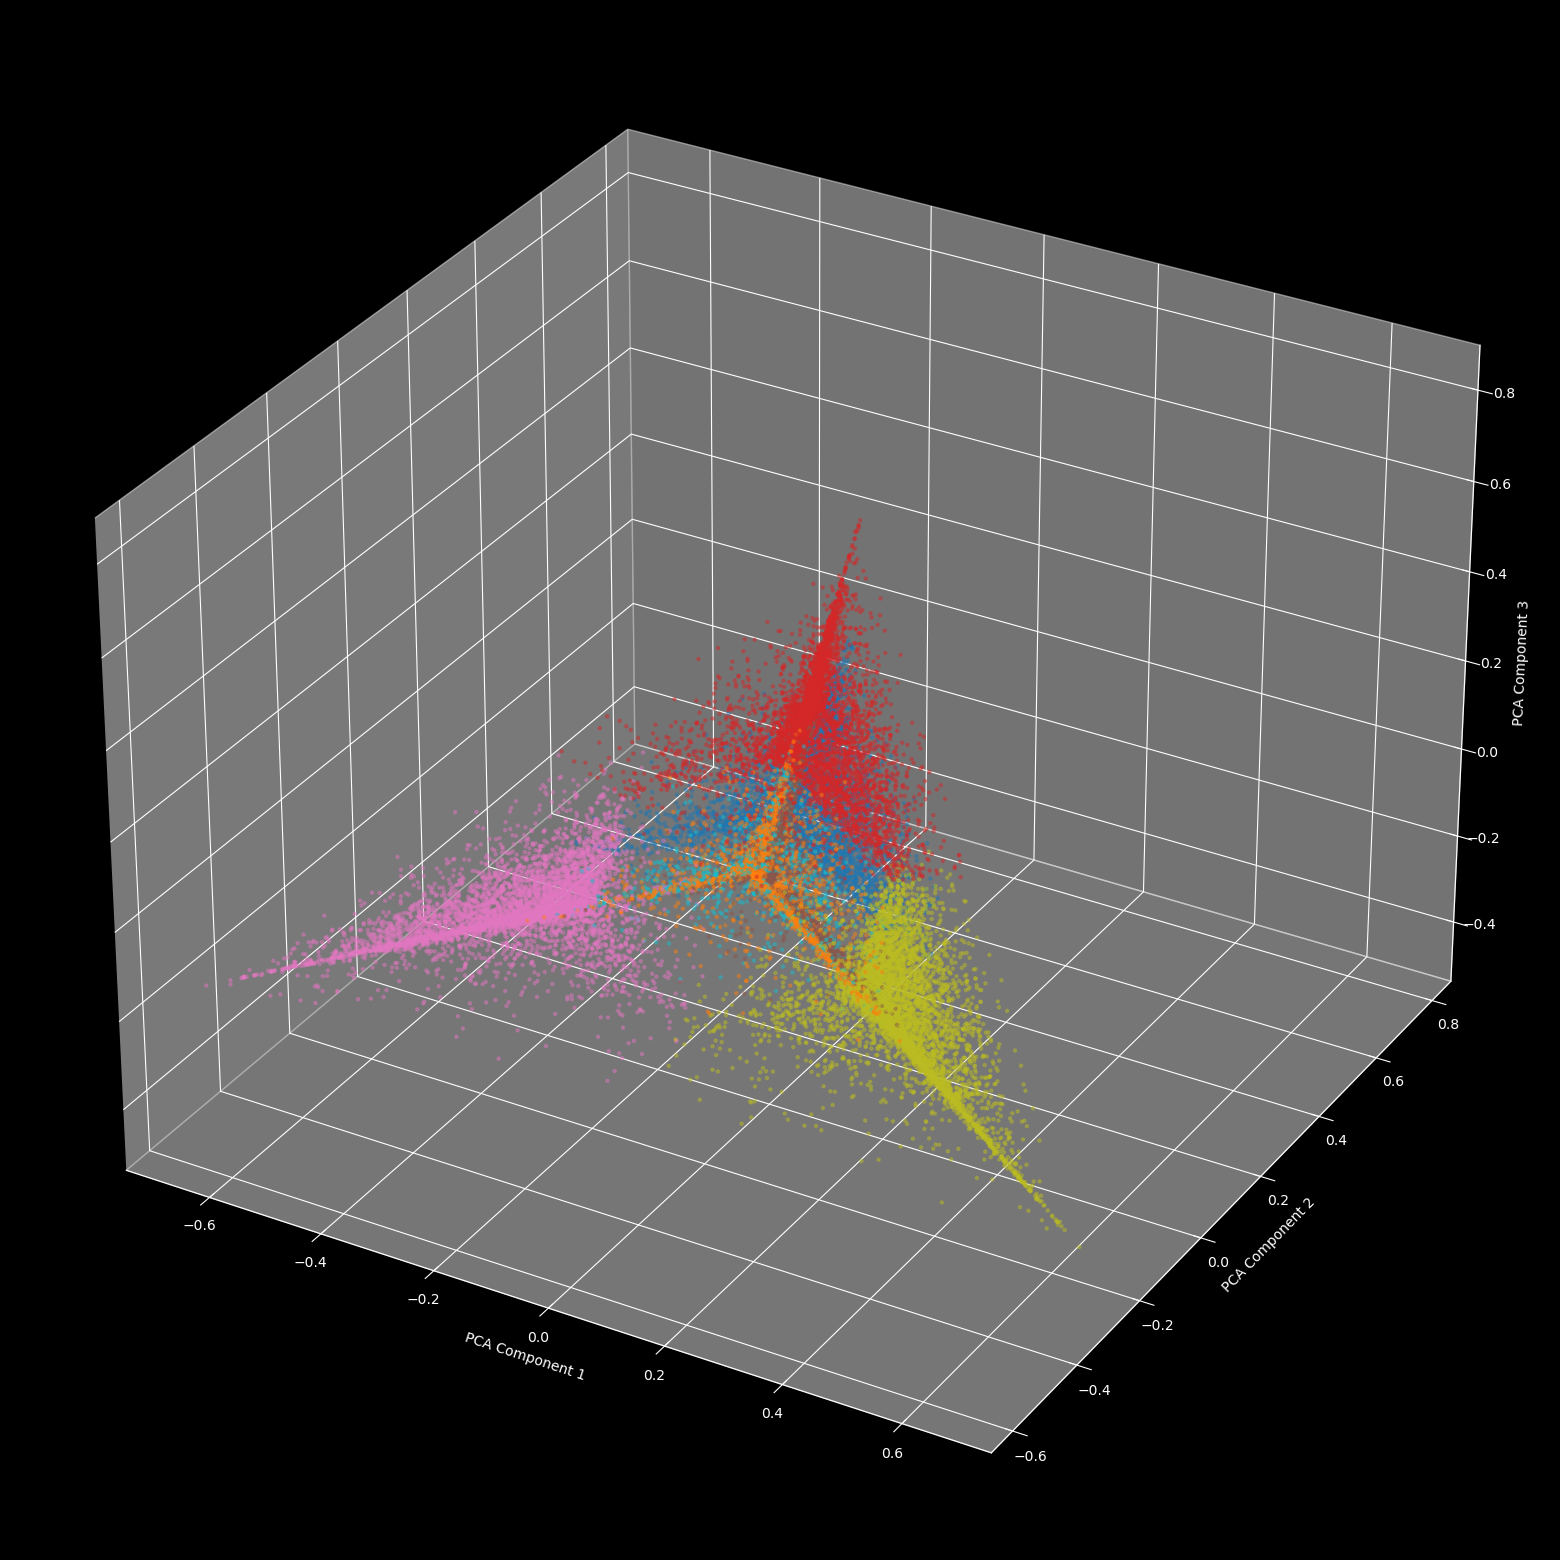

In [29]:
fig = plt.figure()
ax = fig.add_subplot(projection='3d')
ax.scatter(X_pca[:, 0], X_pca[:, 1], X_pca[:, 2], c=labels, cmap='tab10', s=5, alpha=0.4)
ax.set_xlabel('PCA Component 1')
ax.set_ylabel('PCA Component 2')
ax.set_zlabel('PCA Component 3')
plt.gcf().set_size_inches((20, 20))
plt.show()

Each dot is a song plotted across the three most important PCA summary directions, with colors representing the 7 clusters KMeans assigned. We can see a slightly better separation between the center clusters compared to the 2D plot, since we're capturing one additional dimension of lyrical variance.

# 5. Cluster Profiling

In [30]:
# Cluster labels 
lyrical_cols = [
    'dating', 'violence', 'world/life', 'night/time', 'shake the audience',
    'family/gospel', 'romantic', 'communication', 'obscene', 'music',
    'movement/places', 'light/visual perceptions', 'family/spiritual', 'sadness', 'feelings'
]

df_profile = df_raw[lyrical_cols].copy() # create new df with just lyrical features for profiling

df_profile['cluster'] = labels # attach cluster labels as a new column, so now each row (song) knows which cluster it belongs to
df_profile['genre'] = df_raw['genre'].values # attach genre as new column


df_profile.head()



,dating,violence,world/life,night/time,shake the audience,family/gospel,romantic,communication,obscene,music,movement/places,light/visual perceptions,family/spiritual,sadness,feelings,cluster,genre
0,0.000598,0.063746,0.000598,0.000598,0.000598,0.048857,0.017104,0.263751,0.000598,0.039288,0.000598,0.000598,0.000598,0.380299,0.117175,5,pop
1,0.035537,0.096777,0.443435,0.001284,0.001284,0.027007,0.001284,0.001284,0.001284,0.118034,0.001284,0.212681,0.051124,0.001284,0.001284,2,pop
2,0.002770,0.002770,0.002770,0.002770,0.002770,0.002770,0.158564,0.250668,0.002770,0.323794,0.002770,0.002770,0.002770,0.002770,0.225422,1,pop
3,0.048249,0.001548,0.001548,0.001548,0.021500,0.001548,0.411536,0.001548,0.001548,0.001548,0.129250,0.001548,0.001548,0.225889,0.001548,3,pop
4,0.001350,0.001350,0.417772,0.001350,0.001350,0.001350,0.463430,0.001350,0.001350,0.001350,0.001350,0.001350,0.029755,0.068800,0.001350,3,pop


In [31]:
print(max(4, best_k * 0.8))

5.6000000000000005


##### Dominant Features

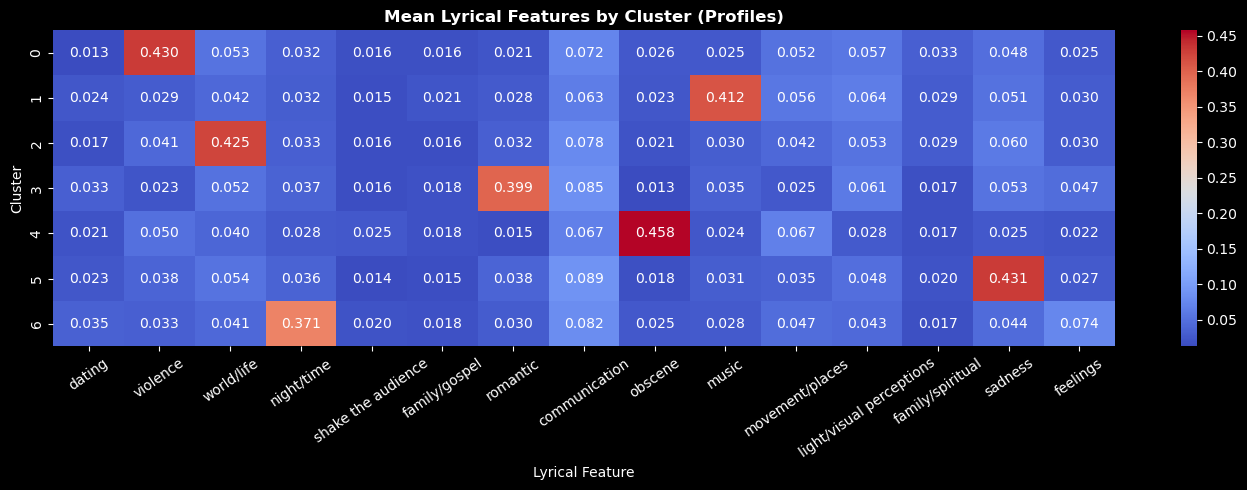

In [32]:
cluster_means = df_profile.groupby('cluster')[lyrical_cols].mean()
cluster_means.round(3)


# Heatmap of cluster means
fig, ax = plt.subplots(figsize=(14, 5))
sns.heatmap(cluster_means, annot=True, fmt='.3f', cmap='coolwarm', ax=ax)
ax.set_title('Mean Lyrical Features by Cluster (Profiles)', fontsize=12, fontweight='bold', color='white')
ax.set_xlabel('Lyrical Feature')
ax.set_ylabel('Cluster')
ax.tick_params(axis='x', rotation=35)


plt.tight_layout()
plt.show()

Each cluster showed a red-ish cell which is the highest mean value in that cluster.

Their dominant lyrical features are:
- Cluster 0 — high violence (0.430)
- Cluster 1 — high music (0.412)
- Cluster 2 — high world/life (0.425) 
- Cluster 3 — high romantic (0.399)
- Cluster 4 — high obscene (0.458) 
- Cluster 5 — high sadness (0.431)
- Cluster 6 — high night/time (0.371) 

Everything else stayed low in mean value, meaning our KMeans model found 7 genuinely distinct lyrical identities which proves we have chosen the a well-justified K-value.

In [33]:
# Cluster size summary 
cluster_counts = df_profile['cluster'].value_counts().sort_index() # count how many songs are in each cluster and sort
print('Songs per cluster:')

for c, n in cluster_counts.items():
    percent = n/len(df_profile)*100 # calculate percentage of each cluster's songs out of all songs
    print(f'  Cluster {c}: {n:,} songs ({percent:.1f}%)')


Songs per cluster:
  Cluster 0: 5,764 songs (20.3%)
  Cluster 1: 2,364 songs (8.3%)
  Cluster 2: 5,480 songs (19.3%)
  Cluster 3: 1,625 songs (5.7%)
  Cluster 4: 4,932 songs (17.4%)
  Cluster 5: 6,122 songs (21.6%)
  Cluster 6: 2,075 songs (7.3%)


# 6. Save Clustered Dataset

Merge the cluster labels back onto the original train.csv

In [34]:
# Load original train.csv to get artist/track names back
df_orig = pd.read_csv('../data/train.csv')

# Attach cluster labels (same row order as train_cleaned.csv)
df_orig['cluster'] = labels

df_orig.to_csv('../data/clustered_data/clustered_train.csv', index=False)

print(f'Saved clustered_train.csv — shape: {df_orig.shape}')

df_orig[['artist_name', 'track_name', 'genre', 'cluster']].head(10)

Saved clustered_train.csv — shape: (28362, 25)


,artist_name,track_name,genre,cluster
0,mukesh,mohabbat bhi jhoothi,pop,5
1,frankie laine,i believe,pop,2
2,johnnie ray,cry,pop,1
3,pérez prado,patricia,pop,3
4,giorgos papadopoulos,apopse eida oneiro,pop,3
5,perry como,round and round (with mitchell ayres and his o...,pop,0
6,freestyle,opm medley: when i met you,pop,2
7,johnny mathis,it's not for me to say,pop,2
8,stélios kazantzídis,klapse me mana klapse me,pop,3
9,stélios kazantzídis,finito la mouzika,pop,5
